### **TIME SERIES MODELING OF THE DAILY INFLATION ADJUSTMENT INDEX AND ITS IMPLICATIONS FOR INFLATION MEASUREMENT IN PERU**

**Author:** Hesler Bustos Chavez   
**Project Context:** Applied Time Series and Economic Modeling with Python

## Project summary

Inflation represents a continuous decrease in the purchasing power of a currency, negatively affecting economic stability. In Peru, its primary indicator is the Consumer Price Index (CPI), calculated monthly by the National Institute of Statistics and Informatics (INEI). Based on this metric, the Central Reserve Bank of Peru (BCRP) establishes the Daily Readjustment Index (IRD), a mathematical factor designed to update financial liabilities in the national currency (soles) for terms of no less than 90 days, aiming to maintain the constant value of these amounts relative to inflation.

This project demonstrates the utility of historical Daily Readjustment Index (IRD) data in reconstructing monthly variations of the Consumer Price Index (CPI). Furthermore, it illustrates how this information enables the analysis of inflationary dynamics and the projection of short-term purchasing power loss. The study combines mathematical formulation, economic interpretation, and computational analysis in Python.

## Economic Background

Macroeconomic literature indicates that unstable inflation increases overall uncertainty. This necessitates the incorporation of risk premiums, directly raising the cost of financing. As a result of this dynamic, a distortion in the efficient allocation of resources occurs (Fischer, 1993; Bruno & Easterly, 1998; Lucas, 1973).

To understand the structural need for readjustment mechanisms, it is imperative to refer to the classical economic theory proposed by Irving Fisher (1930). The "Fisher Equation" postulates that the nominal interest rate ($i$) agreed upon in a financial obligation is composed of the real interest rate ($r$) demanded by the creditor and the expected inflation rate ($\pi^e$):$$1 + i = (1 + r)(1 + \pi^e)$$In a financial environment without indexation, the creditor assumes the risk that observed inflation will exceed projected inflation. To mitigate this asymmetry, markets incorporate an inflationary risk premium that artificially raises nominal rates to compensate for the uncertainty.

Within our study, an analytical challenge arises: financial liabilities accrue interest in a continuous-time environment (daily), whereas the publication of the CPI provides a discrete variable (monthly). The Daily Readjustment Index (IRD) acts as a mathematical bridge, applying a deterministic exponential interpolation over the discrete CPI data. By indexing the principal of the debt on a daily basis, the IRD eliminates the need to estimate future variables ($\pi^e$) within contracts, guaranteeing the preservation of the original capital's purchasing power over time.

Given the inertial and autoregressive behavior that characterizes inflation, forecasting the IRD cannot be limited to simple linear extrapolations. This project implements the classical Box and Jenkins (1976) methodology through ARIMA (Autoregressive Integrated Moving Average) models. This stochastic approach allows for modeling the temporal variance and memory of the index series, providing robust estimates of short-term monetary depreciation, which are essential for precise financial planning.

## Mathematical Formulation

Let:

- $IPC_m$ be the CPI of the previous month
- $D$ the number of days in the month
- $I_d$ the value of the IRD on day $d$
- $I_0$ is the value that the index had on the last day of the previous month.

The IRD is constructed as:

$$
I_d = I_0 \cdot \left(\frac{IPC_m}{IPC_{m-1}}\right)^{\tfrac{d}{D}}
$$

This implies that within each month, the IRD follows a perfect exponential trajectory.

Taking logarithms:

$$
\ln(I_d) = \ln(I_0) + d \cdot \ln\left(\frac{IPC_m}{IPC_{m-1}}\right)^{\tfrac{1}{D}}
$$

Thus, the logarithm of the IRD is linear within each month, and its slope encodes the monthly inflation.

From this construction, CPI variation can be recovered using only IRD values:

$$
\frac{IPC_m}{IPC_{m-1}} = \frac{I_{\text{D}}}{I_{\text{0}}}
$$

The monthly inflation rate is as follows:$$inflation_{m}=\left(\frac{I_D}{I_0}-1\right)100 \%$$


# PROBLEM STATEMENT

Inflation reduces the purchasing power of money and affects economic stability. Inflation is commonly measured by the Consumer Price Index (CPI), which is published monthly. However, the Daily Adjustment Index (DAI) provides daily information that can reflect short-term inflationary dynamics. The problem this project addresses is whether historical DAI data can be used to approximate monthly inflationary behavior and analyze short-term changes in purchasing power.

 # PROJECT OBJECTIVES

* Recover monthly CPI inflation rates using continuous daily IRD data.
* Develop and compare alternative time series forecasting models to project the index and assess short-term purchasing power depreciation.

# METHODOLOGY

The Daily Readjustment Index (IRD) was analyzed as a time series to model and forecast its behavior. Several forecasting models were implemented, including ARIMA, SARIMA, Random Forest, XGBoost, and Long Short-Term Memory (LSTM). Model performance was evaluated using the metrics MSE, RMSE, MAE, and MAPE, selecting the model with the lowest prediction error.

# DATA DESCRIPTION
The data used in this project corresponds to the Daily Readjustment Index (IRD) published by the Central Reserve Bank of Peru (BCRP).

* **Frequency:** Daily
* **Source:** [BCRP Statistical Database](https://estadisticas.bcrp.gob.pe/estadisticas/series/)
* **Period:** January 2024 - February 2026

# Environment Setup and Library Imports

In [39]:
# Standard library imports
import sys
import os
import logging
import warnings

warnings.filterwarnings("ignore")

# Add project root to path (for src imports)
sys.path.append(os.path.abspath(".."))

# Data manipulation & numerical computing 
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical time series models 
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Auto-Arima
import pmdarima as pm

# Time series analysis and diagnostics
from statsmodels.tsa.stattools import acf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL

# Machine Learnings models
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Deep Learning(LSTM)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Data preprocessing
from sklearn.preprocessing import MinMaxScaler

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Project modules (src)
from src.data_preprocessing import (
    load_data,
    parse_spanish_dates,
    set_time_index,
    split_time_series,
    add_differencing,
    prepare_scaled_splits
)

from src.utils import (
    save_figure,
    adf_test
)

from src.models import (
    train_arima,
    get_residuals,
    evaluate_arima_model,
    evaluate_models,
    create_sequences
)

from src.evaluation import forecast_metrics

In [40]:
# Load the dataset
df_ird = load_data("../data/raw/indice_reajuste_diario_ird.xlsx")
df_ird.head()

,0,1
0,01Ene24,11.243179
1,02Ene24,11.244647
2,03Ene24,11.246116
3,04Ene24,11.247586
4,05Ene24,11.249055


In [41]:
# Rename columns
df_ird = df_ird.rename(columns={
    df_ird.columns[0]: "Date",
    df_ird.columns[1]: "IRD"
})
df_ird.head()

,Date,IRD
0,01Ene24,11.243179
1,02Ene24,11.244647
2,03Ene24,11.246116
3,04Ene24,11.247586
4,05Ene24,11.249055


In [42]:
# Apply transformation
df_ird = parse_spanish_dates(df_ird, "Date")
df_ird = set_time_index(df_ird, "Date")

# Save
df_ird.to_csv("../data/processed/df_ird.csv", index=False)
df_ird.head()

,IRD
Date,
2024-01-01,11.243179
2024-01-02,11.244647
2024-01-03,11.246116
2024-01-04,11.247586
2024-01-05,11.249055


In [43]:
# Dimensions
df_ird.shape

(565, 1)

In [44]:
# Check for duplicates
print(f'Total duplicates in the dataset: {df_ird.duplicated().sum()}')

Total duplicates in the dataset: 0


In [45]:
# Number of null values
df_ird.isnull().sum()

IRD    0
dtype: int64

In [46]:
# Summary of the DataFrame
df_ird.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 565 entries, 2024-01-01 to 2026-02-27
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   IRD     565 non-null    float64
dtypes: float64(1)
memory usage: 8.8 KB


In [47]:
# Statistical Summary
df_ird.describe().T

,count,mean,std,min,25%,50%,75%,max
IRD,565.0,11.530674,0.121068,11.243179,11.464354,11.5077,11.649225,11.693719


# Preliminary visualization

Figure saved at: ../results/figures\ird_time_series.png


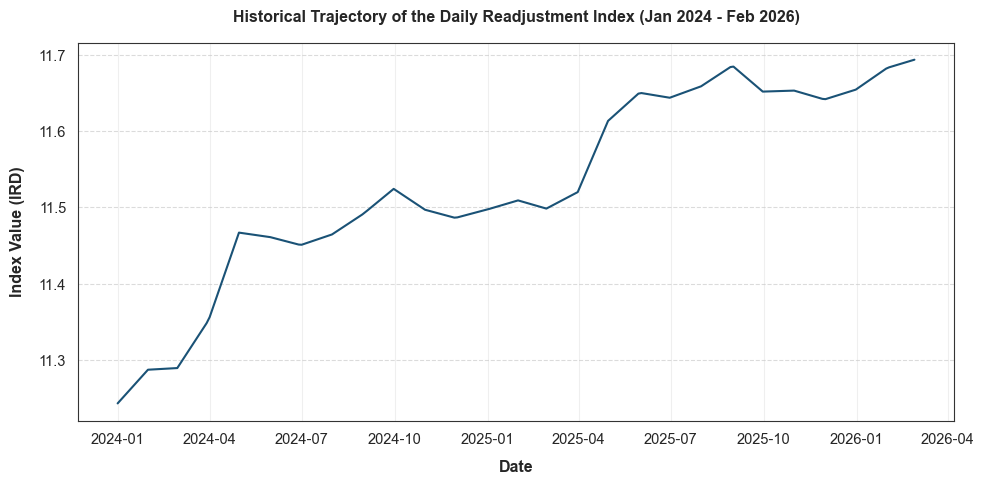

In [48]:
# Set aesthetic configuration
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['axes.edgecolor'] ='#333333'
plt.rcParams['axes.linewidth'] = 0.8

# Initialize the figure with standard proportions
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the continuous time series
sns.lineplot(
    data=df_ird,
    x=df_ird.index,
    y='IRD',
    color='#1A5276',
    linewidth=1.5,
    ax=ax
)

# Configure formal labels and title
ax.set_title('Historical Trajectory of the Daily Readjustment Index (Jan 2024 - Feb 2026)',
             pad=15, fontweight='bold')
ax.set_xlabel('Date', fontweight='bold', labelpad=10)
ax.set_ylabel('Index Value (IRD)', fontweight='bold', labelpad=10)

# Optimize grid lines for readability without cluttering the plot
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', alpha=0.3)

# Ensure optimal spacing
plt.tight_layout()

# Save
save_figure(
    fig,
    path="../results/figures",
    filename="ird_time_series.png"
)

# Display the graphic
plt.show()

Visual inspection of the Daily Readjustment Index suggests a persistent upward trend over the sample period (2024–2026), indicating non-stationarity . No evident seasonal pattern is observed.

# Seasonal-Trend decomposition using Loess (STL)

This section decomposes the series into three fundamental components: trend, seasonal pattern and residual fluctuations. Although the IRD is recorded at a daily frequency, it is derived from the Consumer Price Index (CPI), which is calculated monthly. Therefore, we approximate the seasonal structure using a 30-day cycle to capture potential monthly adjustments.

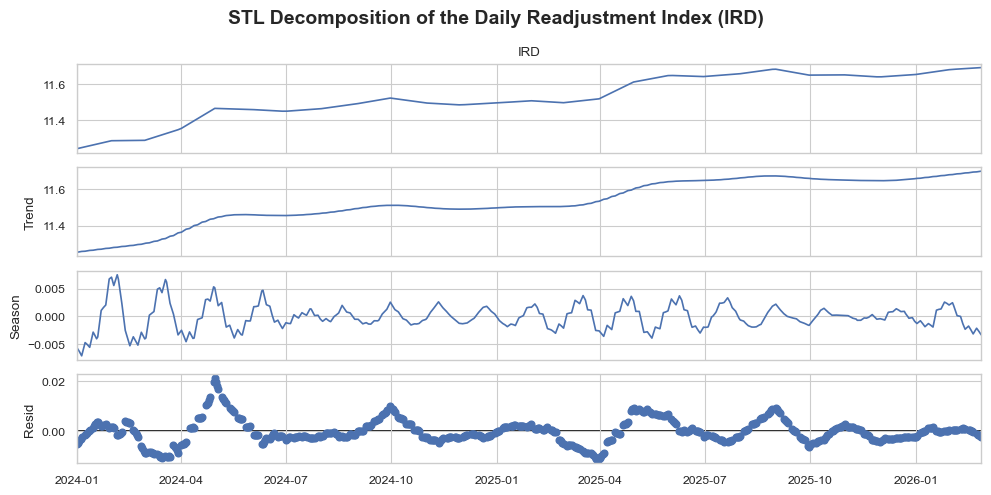

In [49]:
# Set visualization style
sns.set_theme(style="whitegrid", context="paper")

# Apply STL decomposition
stl = STL(df_ird['IRD'].dropna(), period=30)

# Fit the model
res = stl.fit()

# Plot the decomposition components
fig = res.plot()

# Improve figure formatting
fig.set_size_inches(10, 5)
fig.suptitle(
    "STL Decomposition of the Daily Readjustment Index (IRD)",
    fontsize=14,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

* The trend shows a clear and persistent upward movement throughout the sample period.

* The seasonal component exhibits small oscillations around zero with a relatively low amplitude, suggesting that seasonal effects are weak and do not dominate the series' behavior.

* The residual component remains centered around zero with limited volatility, indicating that most of the variation is captured by the trend.

# Data Partitioning: Chronological Train-Validation-Test Split

In [50]:
df_ird_train, df_ird_valid, df_ird_test = split_time_series(df_ird)

print(f"{'DATASET PARTITION SUMMARY (CHRONOLOGICAL)':^70}")
print("-" * 70)
print(f"Training Set   (70%): {df_ird_train.index.min()} to {df_ird_train.index.max()} | n = {len(df_ird_train)}")
print(f"Validation Set (15%): {df_ird_valid.index.min()} to {df_ird_valid.index.max()} | n = {len(df_ird_valid)}")
print(f"Testing Set    (15%): {df_ird_test.index.min()} to {df_ird_test.index.max()} | n = {len(df_ird_test)}")

              DATASET PARTITION SUMMARY (CHRONOLOGICAL)               
----------------------------------------------------------------------
Training Set   (70%): 2024-01-01 00:00:00 to 2025-07-04 00:00:00 | n = 395
Validation Set (15%): 2025-07-07 00:00:00 to 2025-10-30 00:00:00 | n = 84
Testing Set    (15%): 2025-10-31 00:00:00 to 2026-02-27 00:00:00 | n = 86


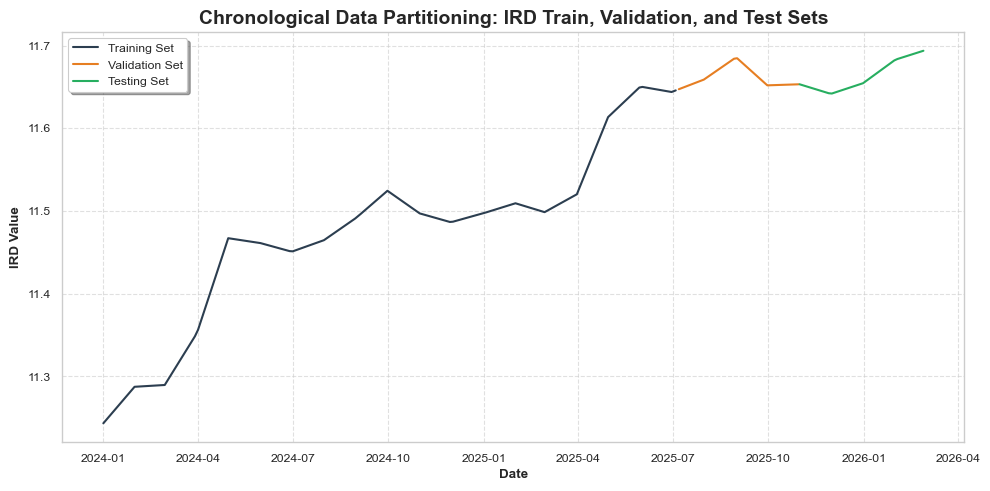

In [51]:
# Visualizing the Data Split
fig, ax = plt.subplots(figsize=(10, 5))

# Plot each partition with distinct, professional colors
ax.plot(df_ird_train.index, df_ird_train['IRD'], label='Training Set', color='#2C3E50', linewidth=1.5)
ax.plot(df_ird_valid.index, df_ird_valid['IRD'], label='Validation Set', color='#E67E22', linewidth=1.5)
ax.plot(df_ird_test.index,  df_ird_test['IRD'],  label='Testing Set', color='#27AE60', linewidth=1.5)

# Apply formatting
ax.set_title('Chronological Data Partitioning: IRD Train, Validation, and Test Sets', fontweight='bold', fontsize=14)
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('IRD Value', fontweight='bold')
ax.grid(axis='both', linestyle='--', alpha=0.6)
ax.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### Formal Stationarity Testing: Augmented Dickey-Fuller (ADF)


* **Null Hypothesis ($H_0$):** The series has a unit root (it is non-stationary).
* **Alternative Hypothesis ($H_1$):** The series has no unit root (it is stationary).

In [52]:
# Preparation
original_series = df_ird_train['IRD'].dropna()

# Test
adf_result = adf_test(original_series)

# Report
print("--- ADF Test Results ---\n")
print(f"Test Statistic: {adf_result['statistic']:.4f}")
print(f"P-value:        {adf_result['p_value']:.4f}")

print("\nCritical Values:")
for key, value in adf_result["critical_values"].items():
    print(f"   {key:>5}: {value:.4f}")

# Interpretation
if adf_result["p_value"] <= 0.05:
    print("=> The series is STATIONARY.")
else:
    print("=> The series is NON-STATIONARY.")

--- ADF Test Results ---

Test Statistic: -1.4507
P-value:        0.5578

Critical Values:
      1%: -3.4474
      5%: -2.8690
     10%: -2.5708
=> The series is NON-STATIONARY.


# Differencing

In [53]:
df_ird_train = add_differencing(df_ird_train, "IRD", order=1)
df_ird_valid = add_differencing(df_ird_valid, "IRD", order=1)
df_ird_test = add_differencing(df_ird_test, "IRD", order=1)


df_ird_train = add_differencing(df_ird_train, "IRD", order=2)
df_ird_valid = add_differencing(df_ird_valid, "IRD", order=2)
df_ird_test = add_differencing(df_ird_test, "IRD", order=2)

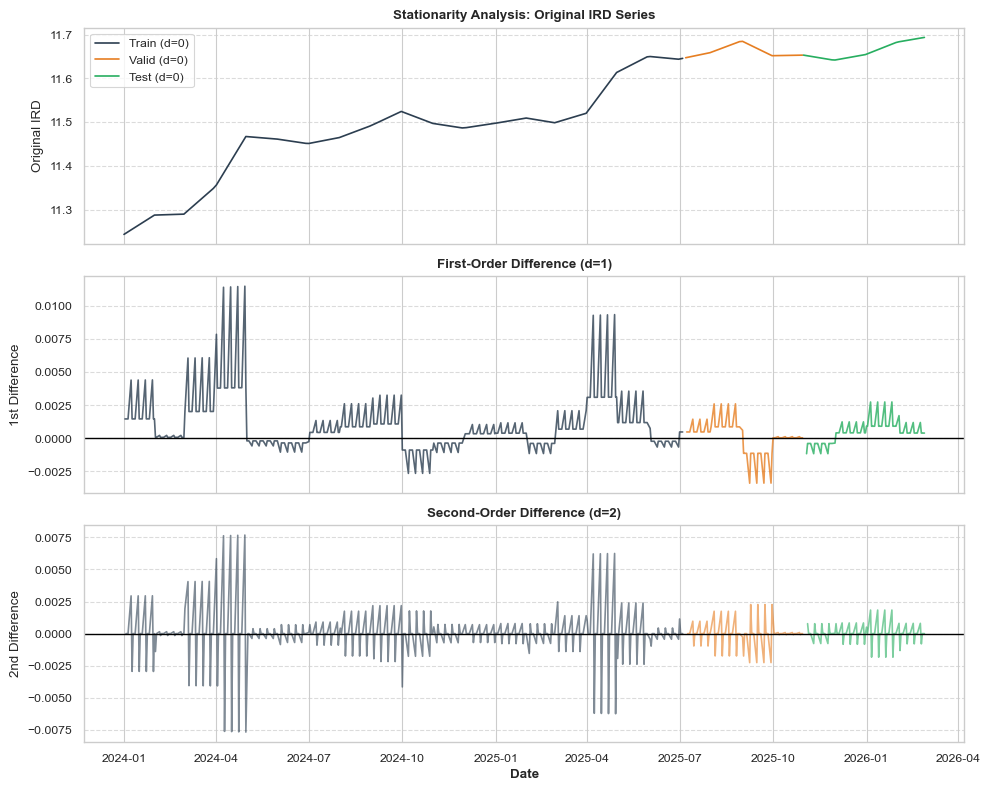

In [54]:
# Visualizing the Integration Order (d) Across Partitions
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Panel 1: Original Base Series (d=0) ---
axes[0].plot(df_ird_train.index, df_ird_train['IRD'], label='Train (d=0)', color='#2C3E50')
axes[0].plot(df_ird_valid.index, df_ird_valid['IRD'], label='Valid (d=0)', color='#E67E22')
axes[0].plot(df_ird_test.index,  df_ird_test['IRD'],  label='Test (d=0)',  color='#27AE60')
axes[0].set_title('Stationarity Analysis: Original IRD Series', fontweight='bold')
axes[0].set_ylabel('Original IRD')
axes[0].legend(loc='upper left')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Panel 2: First-Order Difference (d=1) ---
axes[1].plot(df_ird_train.index, df_ird_train['IRD_diff_1'], color='#2C3E50', alpha=0.8)
axes[1].plot(df_ird_valid.index, df_ird_valid['IRD_diff_1'], color='#E67E22', alpha=0.8)
axes[1].plot(df_ird_test.index,  df_ird_test['IRD_diff_1'],  color='#27AE60', alpha=0.8)
axes[1].set_title('First-Order Difference (d=1)', fontweight='bold')
axes[1].set_ylabel('1st Difference')
axes[1].axhline(0, color='black', linewidth=1, linestyle='-')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Panel 3: Second-Order Difference (d=2) ---
axes[2].plot(df_ird_train.index, df_ird_train['IRD_diff_2'], color='#2C3E50', alpha=0.6)
axes[2].plot(df_ird_valid.index, df_ird_valid['IRD_diff_2'], color='#E67E22', alpha=0.6)
axes[2].plot(df_ird_test.index,  df_ird_test['IRD_diff_2'],  color='#27AE60', alpha=0.6)
axes[2].set_title('Second-Order Difference (d=2)', fontweight='bold')
axes[2].set_xlabel('Date', fontweight='bold')
axes[2].set_ylabel('2nd Difference')
axes[2].axhline(0, color='black', linewidth=1, linestyle='-')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Formal Stationarity Testing: Augmented Dickey-Fuller (ADF)


* **Null Hypothesis ($H_0$):** The series has a unit root (it is non-stationary).
* **Alternative Hypothesis ($H_1$):** The series has no unit root (it is stationary).

In [55]:
# Isolate the original IRD series, dropping any potential NaNs to prevent errors
original_series = df_ird_train['IRD_diff_1'].dropna()

# Test
adf_result = adf_test(original_series)

# Report
print("--- ADF Test Results ---\n")
print(f"Test Statistic: {adf_result['statistic']:.4f}")
print(f"P-value:        {adf_result['p_value']:.4f}")

print("\nCritical Values:")
for key, value in adf_result["critical_values"].items():
    print(f"   {key:>5}: {value:.4f}")

# Interpretation
if adf_result["p_value"] <= 0.05:
    print("=> The series is STATIONARY.")
else:
    print("=> The series is NON-STATIONARY.")

--- ADF Test Results ---

Test Statistic: -3.1737
P-value:        0.0216

Critical Values:
      1%: -3.4474
      5%: -2.8690
     10%: -2.5708
=> The series is STATIONARY.


The statistical evidence confirms that the transformed series is stationary. Therefore, an integration order of **$d = 1$** is established as the optimal parameter for the Box-Jenkins methodology.

# ACF and PACF Diagnostics

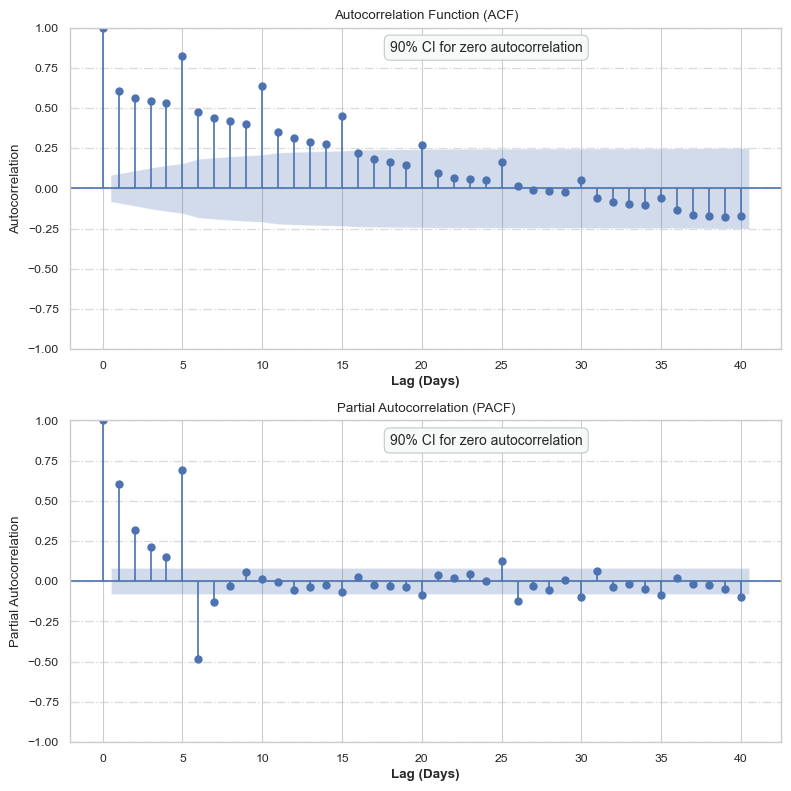

In [56]:
# Isolate the differenced training series and drop the initial NaN
train_stationary = df_ird_train['IRD_diff_1'].dropna()

# Define statistical parameters
alpha_level = 0.1  # 90% Confidence Interval
max_lags = 40
ci_text = f"{int(100*(1-alpha_level))}% CI for zero autocorrelation"

# Setup a 2x1 plot grid
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

# Plot 1: ACF (Determines MA 'q')
plot_acf(train_stationary, ax=axes[0], alpha=alpha_level, lags=max_lags, title='Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lag (Days)', fontweight='bold')
axes[0].set_ylabel('Autocorrelation')
axes[0].grid(axis='y', linestyle='dashdot', linewidth=1, alpha=0.7)
# Insert custom annotation box
axes[0].annotate(ci_text, xy=(max_lags * 0.45, 0.85), fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.4", fc="#F8F9F9", ec="#BDC3C7", alpha=0.9))

# Plot 2: PACF (Determines AR 'p') ---
plot_pacf(train_stationary, ax=axes[1], alpha=alpha_level, lags=max_lags, title='Partial Autocorrelation (PACF)')
axes[1].set_xlabel('Lag (Days)', fontweight='bold')
axes[1].set_ylabel('Partial Autocorrelation')
axes[1].grid(axis='y', linestyle='dashdot', linewidth=1, alpha=0.7)
# Insert custom annotation box
axes[1].annotate(ci_text, xy=(max_lags * 0.45, 0.85), fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.4", fc="#F8F9F9", ec="#BDC3C7", alpha=0.9))

plt.tight_layout()
plt.show()

The ACF exhibits a gradual decay across several lags, while the PACF shows significant spikes in the first few lags followed by values within the confidence interval. This pattern suggests a predominantly autoregressive structure in the differenced IRD series.

# Model 1: ARIMA (AutoRegressive Integrated Moving Average)

In [57]:
warnings.filterwarnings("ignore")

model_fit = train_arima(df_ird_train['IRD'], order=(5,1,0))
residuals = get_residuals(model_fit)

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    IRD   No. Observations:                  395
Model:                 ARIMA(5, 1, 0)   Log Likelihood                2140.622
Date:                Sun, 22 Mar 2026   AIC                          -4269.243
Time:                        03:21:39   BIC                          -4245.385
Sample:                    01-01-2024   HQIC                         -4259.789
                         - 07-04-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2085      0.031      6.806      0.000       0.148       0.269
ar.L2          0.0872      0.027      3.203      0.001       0.034       0.141
ar.L3          0.0223      0.031      0.729      0.4

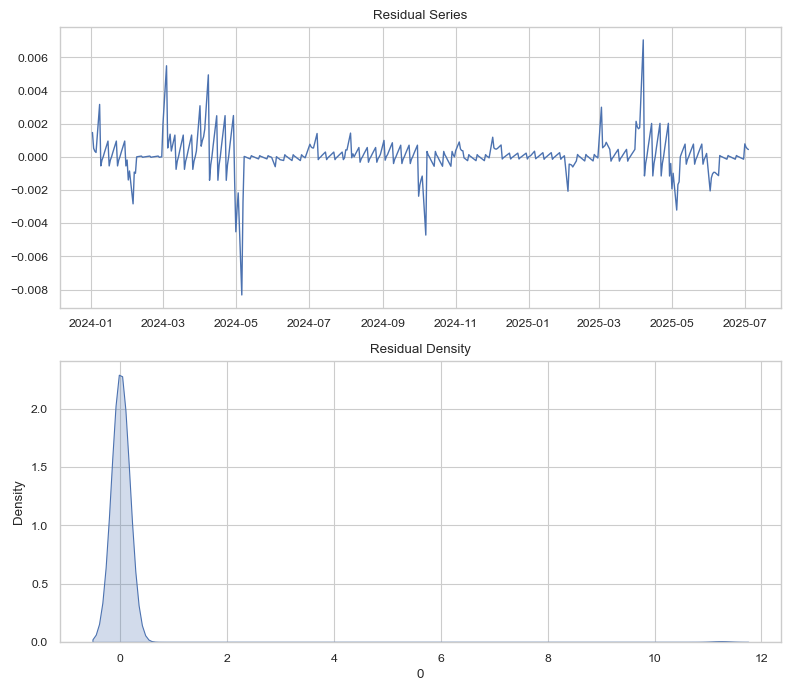

In [58]:
residuals = pd.DataFrame(residuals)

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(8,7))

axes[0].plot(residuals[1:], linewidth=1)
axes[0].set_title("Residual Series")

sns.kdeplot(residuals.squeeze(), ax=axes[1], fill=True)
axes[1].set_title("Residual Density")

plt.tight_layout()
plt.show()

In [59]:
# Residuals Descriptive Statistics
print(residuals.describe())

                  0
count  3.950000e+02
mean   2.850490e-02
std    5.657046e-01
min   -8.327841e-03
25%   -1.456085e-04
50%    9.789876e-07
75%    2.547653e-04
max    1.124318e+01


The residual diagnostics suggest that the estimated ARIMA model adequately captures the underlying dynamics of the series. The residuals fluctuate randomly around zero without displaying any systematic pattern or visible trend. Furthermore, the residual density appears approximately symmetric and centered near zero, indicating that most forecasting errors are small. These characteristics are consistent with a white noise process, suggesting that the model has adequately extracted the temporal structure of the data.

Test MSE: 0.000001144
Test RMSE: 0.001069430


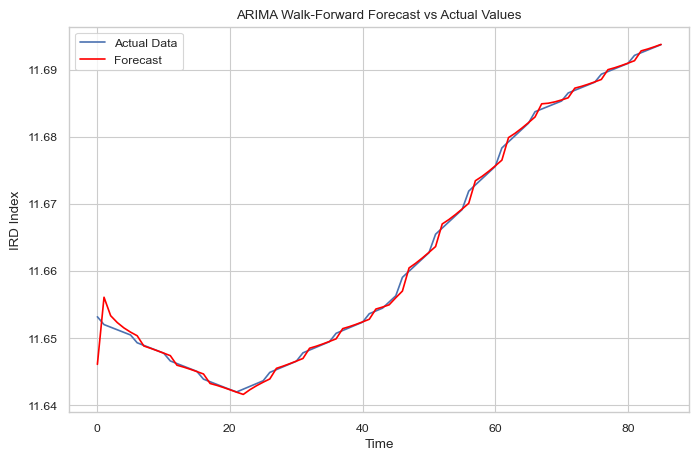

In [60]:
warnings.filterwarnings("ignore")

# Initialize an empty list to store predictions
predictions = []

# Split the series into training and testing arrays
train, test = df_ird_train.IRD.values, df_ird_test.IRD.values

# Initialize history with the training observations
# This will be updated step-by-step during forecasting
history = [x for x in train]

# Walk-forward validation
# The model is re-estimated at each step using all available observations
for t in range(len(test)):

    # Fit an ARIMA model using the available history
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()

    # Generate a one-step-ahead forecast
    output = model_fit.forecast()
    yhat = output[0]

    # Store the forecast in the predictions list
    predictions.append(yhat)

    # Get the actual observation from the test set
    obs = test[t]

    # Update the history with the real observation
    # This simulates how forecasting works in real time
    history.append(obs)

# Compute Mean Squared Error (MSE)
mse = mean_squared_error(test, predictions)

# Compute Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print('Test MSE: %.9f' % mse)
print('Test RMSE: %.9f' % rmse)

# Plot actual values vs predictions
plt.figure(figsize=(8,5))
plt.plot(test, label="Actual Data")
plt.plot(predictions, color='red', label="Forecast")
plt.title("ARIMA Walk-Forward Forecast vs Actual Values")
plt.xlabel("Time")
plt.ylabel("IRD Index")
plt.legend()
plt.show()

In [61]:
p_values = range(0, 7) #[0,1,2,3,4,5,6]
d_values = range(0, 2) #[0,1]
q_values = range(0, 2) #[0,1]

evaluate_models(df_ird_train, df_ird_valid, 'IRD', p_values, d_values, q_values)

ARIMA(0, 0, 0) MSE=0.029119682
ARIMA(0, 0, 1) MSE=0.007265013
ARIMA(0, 1, 0) MSE=0.000001432
ARIMA(0, 1, 1) MSE=0.000001034
ARIMA(1, 1, 0) MSE=0.000000773
ARIMA(1, 1, 1) MSE=0.000000645
ARIMA(5, 1, 0) MSE=0.000000518
ARIMA(5, 1, 1) MSE=0.000000495
ARIMA(6, 1, 0) MSE=0.000000379
Best ARIMA(6, 1, 0) MSE=0.000000379


In [62]:
# Best ARIMA
evaluate_arima_model(df_ird_train, df_ird_test, 'IRD', (6, 1, 0))

1.6813628198574832e-06

Test MSE: 0.000001682


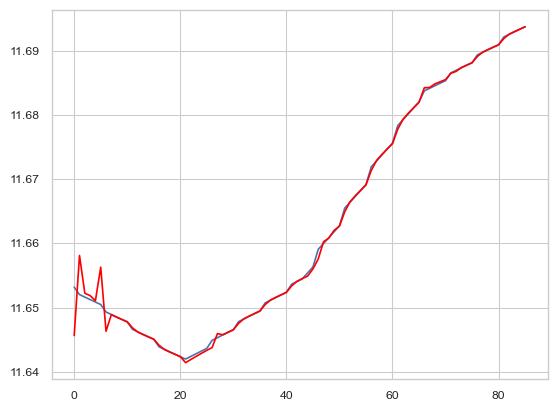

In [63]:
warnings.filterwarnings("ignore")

predictions=[]
train, test = df_ird_train.IRD.values, df_ird_test.IRD.values
history = [x for x in train]
for t in range(len(test)):
	model = ARIMA(history, order=(6,1,0))
	model_fit = model.fit()
	output = model_fit.forecast()
	yhat = output[0]
	predictions.append(yhat)
	obs = test[t]
	history.append(obs)
mse = mean_squared_error(test, predictions)
print('Test MSE: %.9f' % mse)
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

In [64]:
# Summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  480
Model:                 ARIMA(6, 1, 0)   Log Likelihood                2631.902
Date:                Sun, 22 Mar 2026   AIC                          -5249.804
Time:                        03:29:09   BIC                          -5220.602
Sample:                             0   HQIC                         -5238.324
                                - 480                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4478      0.020     22.867      0.000       0.409       0.486
ar.L2          0.0826      0.025      3.335      0.001       0.034       0.131
ar.L3          0.0457      0.033      1.399      0.1

### Using the autoarima function

In [65]:
# Autoarima function
model_arima = pm.auto_arima(df_ird_train['IRD'],
                      start_p=0,
                      max_p=6,
                      start_q=0,
                      max_q=3,
                      d=1,
                      seasonal=False,
                      trace=True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-3769.794, Time=0.17 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-3945.374, Time=0.18 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-3876.446, Time=0.27 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-3681.484, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-3984.731, Time=0.20 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-4000.290, Time=0.27 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=-4007.581, Time=0.37 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=-4268.594, Time=0.43 sec
 ARIMA(6,1,0)(0,0,0)[0] intercept   : AIC=-4374.359, Time=0.56 sec
 ARIMA(6,1,1)(0,0,0)[0] intercept   : AIC=-3835.353, Time=0.33 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=-4282.709, Time=0.36 sec
 ARIMA(6,1,0)(0,0,0)[0]             : AIC=-4373.488, Time=0.39 sec

Best model:  ARIMA(6,1,0)(0,0,0)[0] intercept
Total fit time: 3.585 seconds


In [66]:
# Generate forecasts for the validation horizon using the fitted ARIMA model
n_valid = len(df_ird_valid)

future_forecast, conf_int = model_arima.predict(
    n_periods=n_valid,
    return_conf_int=True
)

# Convert validation values to numpy array
y_valid_actual = df_ird_valid['IRD'].values

# Print results
mse_arima, rmse_arima, mae_arima, mape_arima = forecast_metrics(y_valid_actual, future_forecast)

# Print results
print("ARIMA Validation Performance")
print("-"*40)

print(f"MSE  : {mse_arima:.6f}")
print(f"RMSE : {rmse_arima:.6f}")
print(f"MAE  : {mae_arima:.6f}")
print(f"MAPE : {mape_arima:.4f}%")

ARIMA Validation Performance
----------------------------------------
MSE  : 0.000932
RMSE : 0.030531
MAE  : 0.020859
MAPE : 0.1790%


In [67]:
# Align the forecast index with the validation dataset index
future_forecast.index = df_ird_valid.index

Figure saved at: ../results/figures\arima_forecast.png


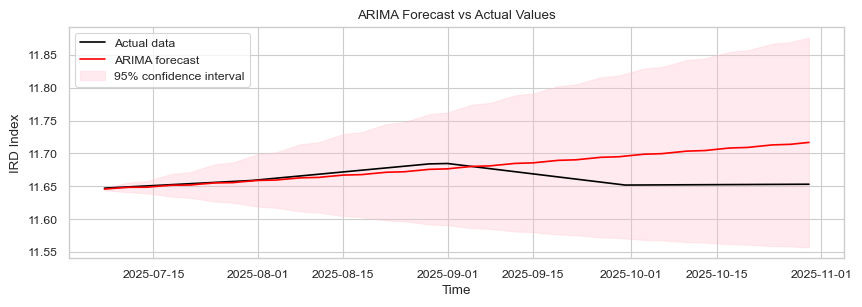

In [68]:
# Create figure
fig, ax = plt.subplots(figsize=(10,3))

# Plot actual validation data
ax.plot(df_ird_valid.index, df_ird_valid.IRD,
        label="Actual data", color="black")

# Plot ARIMA forecast
ax.plot(future_forecast.index, future_forecast,
        label="ARIMA forecast", color="red")

# Plot confidence intervals
ax.fill_between(
    future_forecast.index,
    conf_int[:,0],
    conf_int[:,1],
    color="pink",
    alpha=0.3,
    label="95% confidence interval"
)

# Labels and legend
ax.set_title("ARIMA Forecast vs Actual Values")
ax.set_xlabel("Time")
ax.set_ylabel("IRD Index")
ax.legend(loc="best")

save_figure(
    fig,
    path="../results/figures",
    filename="arima_forecast.png"
)

plt.show()

The model initially tracks the observed series closely, indicating that it captures the short-term dynamics of the IRD index. However, as the forecast horizon increases, the predicted values exhibit a slight upward trend while the observed series stabilizes, suggesting a modest overestimation by the model. Importantly, the observed values remain within the confidence bounds, indicating that the model's predictions remain statistically plausible despite the growing uncertainty.

# Model 2: SARIMA (Seasonal ARIMA)


Forecast evaluation metrics (Validation set)
---------------------------------------------
MSE :  0.000000
RMSE:  0.000636
MAE :  0.000351
MAPE:  0.0030%
Figure saved at: ../results/figures\sarima_forecast.png


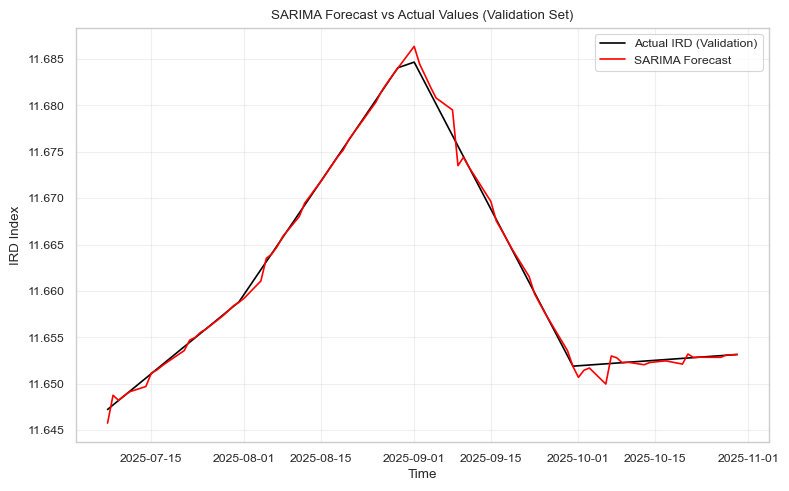

In [69]:
warnings.filterwarnings("ignore")

# Training and validation data
train = df_ird_train['IRD'].values
valid = df_ird_valid['IRD'].values

# Rolling one-step-ahead forecast using SARIMA
history = list(train)
sarima_forecast = []

for t in range(len(valid)):

    # Define SARIMA model
    model_sarima = SARIMAX(history,
                    order=(6,1,0),
                    seasonal_order=(1,0,1,30),
                    enforce_stationarity=False,
                    enforce_invertibility=False)

    # Fit model
    model_fit_sarima = model_sarima.fit(disp=False)

    # One-step forecast
    yhat = model_fit_sarima.forecast(steps=1)[0]

    # Store prediction
    sarima_forecast.append(yhat)

    # Update history with observed value
    history.append(valid[t])

# Forecast evaluation metrics

mse_sarima, rmse_sarima, mae_sarima, mape_sarima = forecast_metrics(valid, sarima_forecast)

# Print evaluation results
print("\nForecast evaluation metrics (Validation set)")
print("-"*45)
print(f"MSE :  {mse_sarima:.6f}")
print(f"RMSE:  {rmse_sarima:.6f}")
print(f"MAE :  {mae_sarima:.6f}")
print(f"MAPE:  {mape_sarima:.4f}%")

# Visualization: Actual vs SARIMA forecast
plt.figure(figsize=(8,5))

plt.plot(df_ird_valid.index,
         valid,
         label="Actual IRD (Validation)",
         color="black")

plt.plot(df_ird_valid.index,
         sarima_forecast,
         label="SARIMA Forecast",
         color="red")

plt.title("SARIMA Forecast vs Actual Values (Validation Set)")
plt.xlabel("Time")
plt.ylabel("IRD Index")
plt.legend(loc="best")
plt.grid(alpha=0.3)

#Save
save_figure(
    fig,
    path="../results/figures",
    filename="sarima_forecast.png"
)

plt.tight_layout()
plt.show()

A Seasonal ARIMA (SARIMA) model was estimated to account for potential seasonal patterns in the time series. The model specification $SARIMA(6,1,0)(1,0,1)_{30}$ includes both non-seasonal and seasonal autoregressive and moving average components, allowing the model to capture temporal dependencies and possible seasonal dynamics in the IRD series.

# Model 3: Random Forest

Training observations: 389
Validation observations: 78
Test observations: 80

Searching for optimal Random Forest parameters...
Best parameters found:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

VALIDATION PERFORMANCE
----------------------------------------
MSE  : 0.000324
RMSE : 0.017993
MAE  : 0.014259
MAPE : 0.1222%
Figure saved at: ../results/figures\rf_forecast.png


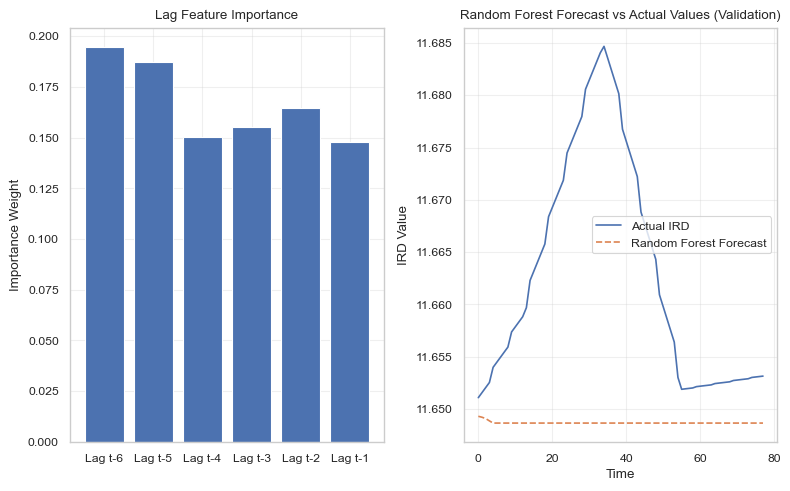

In [70]:
warnings.filterwarnings("ignore")

# Extract IRD values from each dataset split
# Scaling improves performance of tree-based models when features are lags
train_scaled, valid_scaled, test_scaled, scaler_rf = prepare_scaled_splits(
    df_ird_train,
    df_ird_valid,
    df_ird_test,
    target_col="IRD"
)

# Number of lagged observations used as predictors
TIME_STEPS = 6

X_train_rf, y_train_rf = create_sequences(train_scaled, TIME_STEPS)
X_valid_rf, y_valid_rf = create_sequences(valid_scaled, TIME_STEPS)
X_test_rf,  y_test_rf  = create_sequences(test_scaled, TIME_STEPS)

y_train_rf = y_train_rf.ravel()

print(f"Training observations: {len(X_train_rf)}")
print(f"Validation observations: {len(X_valid_rf)}")
print(f"Test observations: {len(X_test_rf)}")

# Grid search is used to find the best Random Forest configuration.
param_grid = {
    "n_estimators": [100,150,200],
    "max_depth": [10,20,None],
    "min_samples_split": [2,5],
    "min_samples_leaf": [1,2]
}

rf_model = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator = rf_model,
    param_grid = param_grid,
    cv = 3,
    n_jobs = -1,
    verbose = 0
)

print("\nSearching for optimal Random Forest parameters...")
grid_search.fit(X_train_rf, y_train_rf)

best_rf = grid_search.best_estimator_

print("Best parameters found:")
print(grid_search.best_params_)

# Validation forecast
fcst_valid_scaled = best_rf.predict(X_valid_rf)

fcst_valid = scaler_rf.inverse_transform(fcst_valid_scaled.reshape(-1,1))
y_valid_actual = scaler_rf.inverse_transform(y_valid_rf.reshape(-1,1))

# Performance metrics (validation)
mse_rf, rmse_rf, mae_rf, mape_rf= forecast_metrics(y_valid_actual, fcst_valid)

print("\nVALIDATION PERFORMANCE")
print("-"*40)
print(f"MSE  : {mse_rf:.6f}")
print(f"RMSE : {rmse_rf:.6f}")
print(f"MAE  : {mae_rf:.6f}")
print(f"MAPE : {mape_rf:.4f}%")

# Feature importance (lag contribution)
feature_importance = best_rf.feature_importances_

# Visualization
fig, axes = plt.subplots(1,2, figsize=(8,5))

# Lag importance
lag_labels = [f"Lag t-{TIME_STEPS-i}" for i in range(TIME_STEPS)]

axes[0].bar(lag_labels, feature_importance)
axes[0].set_title("Lag Feature Importance")
axes[0].set_ylabel("Importance Weight")
axes[0].grid(True, alpha=0.3)

# Forecast vs actual values
axes[1].plot(y_valid_actual, label="Actual IRD")
axes[1].plot(fcst_valid, label="Random Forest Forecast", linestyle="--")

axes[1].set_title("Random Forest Forecast vs Actual Values (Validation)")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("IRD Value")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

save_figure(
    fig,
    path="../results/figures",
    filename="rf_forecast.png"
)

plt.tight_layout()
plt.show()

A Random Forest regression model was implemented to capture potential nonlinear relationships in the IRD time series. Lagged observations were used as predictor variables in order to incorporate temporal dependencies (the number of lagged observations used in the Random Forest model was set to six, consistent with the autoregressive structure identified in the ARIMA(6,1,0) model). Hyperparameters were optimized using grid search with cross-validation, and forecasting performance was evaluated on the validation dataset using MSE, RMSE, MAE, and MAPE.

# Model 4: XGBoost

Training observations: 389
Validation observations: 78

Searching for optimal XGBoost hyperparameters...
Best parameters found:
{'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 200}

VALIDATION PERFORMANCE
----------------------------------------
MSE  : 0.000317
RMSE : 0.017809
MAE  : 0.014041
MAPE : 0.1203%
----------------------------------------
Figure saved at: ../results/figures\xgboost_forecast.png


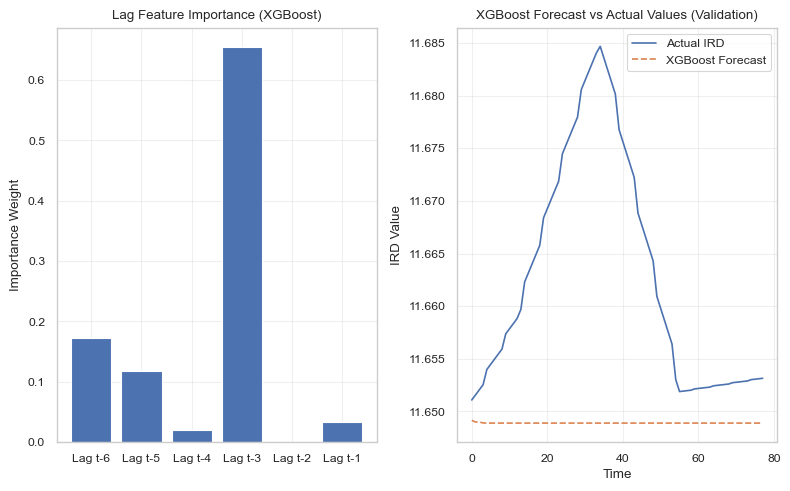

In [71]:
warnings.filterwarnings("ignore")

# Extract IRD values from each dataset split
# Scaling helps stabilize training
train_scaled, valid_scaled, test_scaled, scaler_xgb = prepare_scaled_splits(
    df_ird_train,
    df_ird_valid,
    df_ird_test,
    target_col="IRD"
)

# Number of lagged observations used as predictors
TIME_STEPS = 6

X_train_xgb, y_train_xgb = create_sequences(train_scaled, TIME_STEPS)
X_valid_xgb, y_valid_xgb = create_sequences(valid_scaled, TIME_STEPS)
X_test_xgb,  y_test_xgb  = create_sequences(test_scaled, TIME_STEPS)

y_train_xgb = y_train_xgb.ravel()

print(f"Training observations: {len(X_train_xgb)}")
print(f"Validation observations: {len(X_valid_xgb)}")

# Grid search is used to determine the optimal model configuration.
param_grid_xgb = {
    "n_estimators": [100,150,200],
    "max_depth": [3,5,7],
    "learning_rate": [0.01,0.05,0.1],
    "min_child_weight": [1,2,3]
}

xgb_model = XGBRegressor(
    random_state = 42,
    verbosity = 0,
    objective = "reg:squarederror"
)

grid_search_xgb = GridSearchCV(
    estimator = xgb_model,
    param_grid = param_grid_xgb,
    cv = 3,
    n_jobs = -1,
    verbose = 0
)

print("\nSearching for optimal XGBoost hyperparameters...")
grid_search_xgb.fit(X_train_xgb, y_train_xgb)

best_xgb = grid_search_xgb.best_estimator_

print("Best parameters found:")
print(grid_search_xgb.best_params_)

# Forecast on the validation dataset for model comparison.
fcst_valid_scaled = best_xgb.predict(X_valid_xgb)

fcst_valid = scaler_xgb.inverse_transform(fcst_valid_scaled.reshape(-1,1))
y_valid_actual = scaler_xgb.inverse_transform(y_valid_xgb.reshape(-1,1))

# Performance metrics (validation)
mse_xgb,rmse_xgb,mae_xgb,mape_xgb=forecast_metrics(y_valid_actual, fcst_valid)

print("\nVALIDATION PERFORMANCE")
print("-"*40)
print(f"MSE  : {mse_xgb:.6f}")
print(f"RMSE : {rmse_xgb:.6f}")
print(f"MAE  : {mae_xgb:.6f}")
print(f"MAPE : {mape_xgb:.4f}%")
print("-"*40)

# Feature importance
feature_importance = best_xgb.feature_importances_

# Visualization
fig, axes = plt.subplots(1,2, figsize=(8,5))

# Lag importance
lag_labels = [f"Lag t-{TIME_STEPS-i}" for i in range(TIME_STEPS)]

axes[0].bar(lag_labels, feature_importance)
axes[0].set_title("Lag Feature Importance (XGBoost)")
axes[0].set_ylabel("Importance Weight")
axes[0].grid(True, alpha=0.3)

# Forecast vs actual values
axes[1].plot(y_valid_actual, label="Actual IRD")
axes[1].plot(fcst_valid, label="XGBoost Forecast", linestyle="--")

axes[1].set_title("XGBoost Forecast vs Actual Values (Validation)")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("IRD Value")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

#Save
save_figure(
    fig,
    path="../results/figures",
    filename="xgboost_forecast.png"
)

plt.tight_layout()
plt.show()

An Extreme Gradient Boosting (XGBoost) regression model was implemented to capture potential nonlinear relationships in the IRD time series. Lagged observations were used as predictor variables in order to incorporate temporal dependencies. Hyperparameters were optimized using grid search with cross-validation, and forecasting performance was evaluated on the validation dataset using MSE, RMSE, MAE, and MAPE.

# Model 5: LSTM (Long Short-Term Memory)

Training observations: 389
Validation observations: 78

Training LSTM model...

VALIDATION PERFORMANCE
----------------------------------------
MSE  : 0.000020
RMSE : 0.004434
MAE  : 0.003493
MAPE : 0.0299%
Figure saved at: ../results/figures\lstm_forecast.png


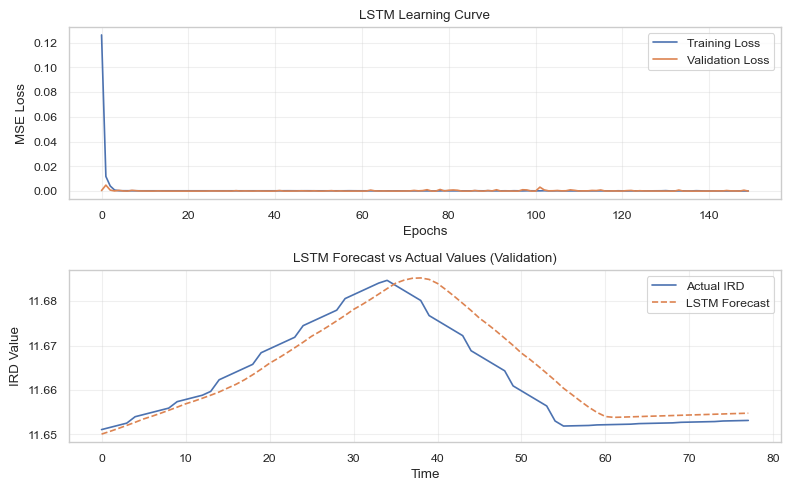

In [72]:
warnings.filterwarnings("ignore")

# Data preparation
# Scaling to stabilize neural network training
train_scaled, valid_scaled, test_scaled, scaler = prepare_scaled_splits(
    df_ird_train,
    df_ird_valid,
    df_ird_test,
    target_col="IRD"
)

# Number of lagged observations used as predictors
TIME_STEPS = 6

X_train, y_train = create_sequences(train_scaled, TIME_STEPS)
X_valid, y_valid = create_sequences(valid_scaled, TIME_STEPS)

# LSTM expects 3D input: [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_valid = X_valid.reshape((X_valid.shape[0], X_valid.shape[1], 1))

print(f"Training observations: {len(X_train)}")
print(f"Validation observations: {len(X_valid)}")

# LSTM architecture
model_lstm = Sequential([

    LSTM(64, activation='tanh', return_sequences=True,
         input_shape=(TIME_STEPS,1)),

    LSTM(32, activation='tanh', return_sequences=True),

    LSTM(16, activation='tanh'),

    Dense(1)
])

model_lstm.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

print("\nTraining LSTM model...")

# Model training
history = model_lstm.fit(

    X_train,
    y_train,

    validation_data=(X_valid, y_valid),

    epochs=150,
    batch_size=16,

    verbose=0
)

# Validation forecast
fcst_valid_scaled = model_lstm.predict(X_valid, verbose=0)

fcst_valid = scaler.inverse_transform(fcst_valid_scaled)
y_valid_actual = scaler.inverse_transform(y_valid.reshape(-1,1))

# Performance metrics
mse_lstm, rmse_lstm, mae_lstm, mape_lstm= forecast_metrics(y_valid_actual, fcst_valid)

print("\nVALIDATION PERFORMANCE")
print("-"*40)
print(f"MSE  : {mse_lstm:.6f}")
print(f"RMSE : {rmse_lstm:.6f}")
print(f"MAE  : {mae_lstm:.6f}")
print(f"MAPE : {mape_lstm:.4f}%")

# Visualization
fig, axes = plt.subplots(2,1, figsize=(8,5))

# Learning curve
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')

axes[0].set_title("LSTM Learning Curve")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Forecast vs actual values
axes[1].plot(y_valid_actual, label='Actual IRD')
axes[1].plot(fcst_valid, label='LSTM Forecast', linestyle='--')

axes[1].set_title("LSTM Forecast vs Actual Values (Validation)")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("IRD Value")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

#Save
save_figure(
    fig,
    path="../results/figures",
    filename="lstm_forecast.png"
)

plt.tight_layout()
plt.show()

A Long Short-Term Memory (LSTM) neural network was implemented to capture nonlinear temporal patterns in the IRD series. The model uses lagged observations as sequential inputs and was trained using the training dataset while monitoring performance on the validation dataset. Forecast accuracy was evaluated using MSE, RMSE, MAE, and MAPE.

The learning curve indicates that the LSTM model converges rapidly during the first training epochs. Training and validation losses stabilize at low values and remain closely aligned, suggesting that the model does not exhibit significant overfitting and generalizes well to unseen data.

# Model Comparison & Summary


MODEL COMPARISON TABLE
        Model Algorithm Type      MSE     RMSE      MAE MAPE (%)
       SARIMA    Statistical 0.000000 0.000636 0.000351  0.0030%
         LSTM  Deep Learning 0.000020 0.004434 0.003493  0.0299%
      XGBoost  Tree Ensemble 0.000317 0.017809 0.014041  0.1203%
Random Forest  Tree Ensemble 0.000324 0.017993 0.014259  0.1222%
        ARIMA    Statistical 0.000932 0.030531 0.020859  0.1790%

BEST PERFORMING MODEL
Model: SARIMA
Algorithm Type: Statistical
MSE: 0.000000404
RMSE: 0.000635598
MAE : 0.000351041
MAPE: 0.0030%


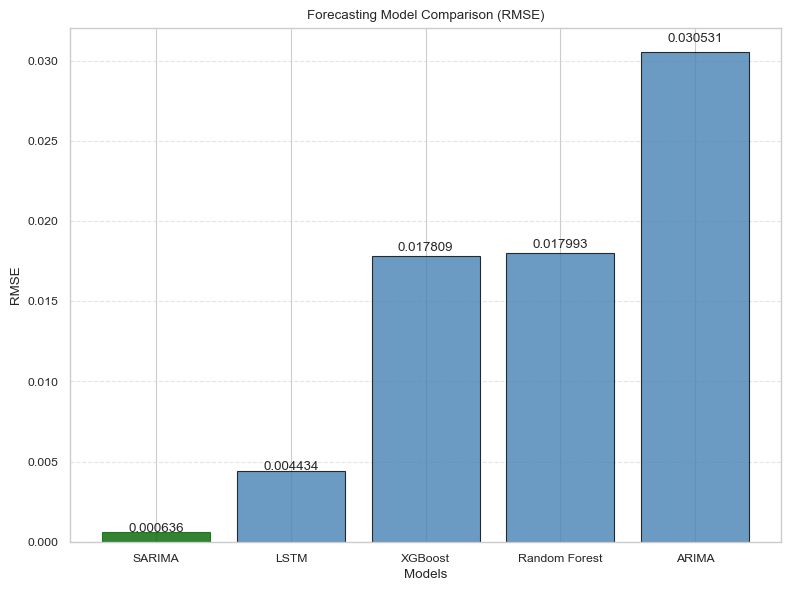

In [73]:
# Create comparison dataframe
df_comparison = pd.DataFrame({

    "Model": [
        "ARIMA",
        "SARIMA",
        "LSTM",
        "Random Forest",
        "XGBoost"
    ],

    "Algorithm Type": [
        "Statistical",
        "Statistical",
        "Deep Learning",
        "Tree Ensemble",
        "Tree Ensemble"
    ],

    "MSE": [
        mse_arima,
        mse_sarima,
        mse_lstm,
        mse_rf,
        mse_xgb
    ],

    "RMSE": [
        rmse_arima,
        rmse_sarima,
        rmse_lstm,
        rmse_rf,
        rmse_xgb
    ],

    "MAE": [
        mae_arima,
        mae_sarima,
        mae_lstm,
        mae_rf,
        mae_xgb
    ],

    "MAPE (%)": [
        mape_arima,
        mape_sarima,
        mape_lstm,
        mape_rf,
        mape_xgb
    ]
})

# Sort models by RMSE
df_comparison = df_comparison.sort_values("RMSE").reset_index(drop=True)

# Formatted table for report
df_formatted = df_comparison.copy()

df_formatted["MSE"] = df_formatted["MSE"].map("{:.6f}".format)
df_formatted["RMSE"] = df_formatted["RMSE"].map("{:.6f}".format)
df_formatted["MAE"] = df_formatted["MAE"].map("{:.6f}".format)
df_formatted["MAPE (%)"] = df_formatted["MAPE (%)"].map("{:.4f}%".format)

print("\nMODEL COMPARISON TABLE")
print("="*70)
print(df_formatted.to_string(index=False))

#Save
df_formatted.to_csv("../results/metrics/model_comparison_report.csv", index=False)

# Identify best model IDENTIFY BEST MODEL
best_model = df_comparison.iloc[0]

print("\nBEST PERFORMING MODEL")
print("="*22)

print(f"Model: {best_model['Model']}")
print(f"Algorithm Type: {best_model['Algorithm Type']}")
print(f"MSE: {best_model['MSE']:.9f}")
print(f"RMSE: {best_model['RMSE']:.9f}")
print(f"MAE : {best_model['MAE']:.9f}")
print(f"MAPE: {best_model['MAPE (%)']:.4f}%")

# Visual comparison
plt.figure(figsize=(8,6))

bars = plt.bar(
    df_comparison["Model"],
    df_comparison["RMSE"],
    edgecolor="black",
    alpha=0.8, color='steelblue'
)

bars[0].set_color("darkgreen")

plt.title("Forecasting Model Comparison (RMSE)")
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + y*0.02, f"{y:.6f}", ha="center")

plt.tight_layout()
plt.show()

Among all evaluated models, SARIMA demonstrated the best predictive performance according to the RMSE metric. This suggests that the IRD time series exhibits strong temporal dependencies and seasonal patterns that are effectively captured by the SARIMA structure.


FORECAST ACCURACY METRICS (TEST SET)
-------------------------------------
MSE  : 0.000227
RMSE : 0.015075
MAE  : 0.012489
MAPE : 0.1070%


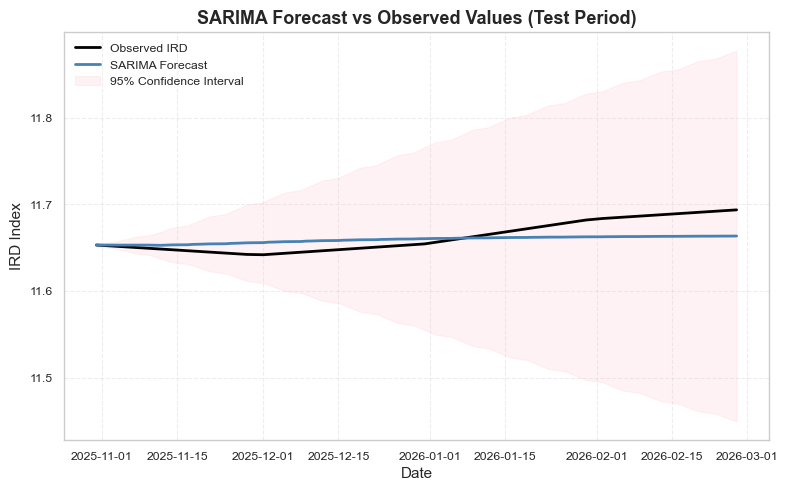

In [74]:
# MODEL EVALUATION BEST MODEL (SARIMA)

n_test = len(df_ird_test)

# Fit Final SARIMA Model
model_fit_sarima_final = model_sarima.fit(disp=False)

# Generate forecasts
forecast_object = model_fit_sarima_final.get_forecast(steps=n_test)

forecast_test = forecast_object.predicted_mean
confidence_intervals = forecast_object.conf_int()

# Extract Confidence Intervals (numpy format)
lower_ci = confidence_intervals[:,0]
upper_ci = confidence_intervals[:,1]

# Forecast Accuracy Metrics
y_test_actual = df_ird_test["IRD"].values

mse_test, rmse_test, mae_test, mape_test =forecast_metrics(y_test_actual, forecast_test)

print("\nFORECAST ACCURACY METRICS (TEST SET)")
print("-"*37)
print(f"MSE  : {mse_test:.6f}")
print(f"RMSE : {rmse_test:.6f}")
print(f"MAE  : {mae_test:.6f}")
print(f"MAPE : {mape_test:.4f}%")

# Forecast Visualization
plt.figure(figsize=(8,5))

plt.plot(
    df_ird_test.index,
    y_test_actual,
    label="Observed IRD",
    color="black",
    linewidth=2
)

plt.plot(
    df_ird_test.index,
    forecast_test,
    label="SARIMA Forecast",
    color="steelblue",
    linewidth=2
)

plt.fill_between(
    df_ird_test.index,
    lower_ci,
    upper_ci,
    color="pink",
    alpha=0.20,
    label="95% Confidence Interval"
)

plt.title(
    "SARIMA Forecast vs Observed Values (Test Period)",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=11)
plt.ylabel("IRD Index", fontsize=11)

plt.legend(frameon=False)
plt.grid(True, linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

The SARIMA model is able to capture the overall level of the IRD time series during the test period. While the observed values display a mild upward trend, the SARIMA forecasts remain relatively stable. Importantly, the observed values remain largely within the 95% confidence interval of the forecast, suggesting that the model provides statistically consistent predictions despite the increasing forecast uncertainty over time.

# **Results and Discussion**

Several forecasting models were evaluated to predict the IRD time series, including ARIMA, SARIMA, Random Forest, XGBoost, and LSTM. Model performance was assessed using four error metrics: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and Mean Absolute Percentage Error (MAPE).

Based on the validation results, the SARIMA model achieved the lowest prediction errors among all evaluated models. This suggests that the IRD series contains seasonal and temporal dependencies that are effectively captured by seasonal autoregressive models.

The final evaluation was conducted on the unseen test dataset. The SARIMA forecasts follow the overall level of the observed IRD values, indicating that the model is able to capture the general dynamics of the series. Although the observed values show a slight upward trend during the test period, the forecast remains close to the actual observations.

Furthermore, most observed values lie within the 95% confidence interval of the forecasts, suggesting that the model provides statistically consistent predictions. These results indicate that the SARIMA model is an appropriate approach for forecasting the IRD index in this study.

## IMPLIED MONTHLY INFLATION FROM IRD FORECAST

Given the construction of the IRD index, the monthly inflation rate can be recovered from the ratio between the last IRD value of the current month and the last value of the previous month. Using the SARIMA forecasts of the IRD series, we compute the implied monthly inflation as the percentage change between these two values.

In [75]:
# Create dataframe with forecast
df_forecast = pd.DataFrame({
    "Date": df_ird_test.index,
    "IRD_forecast": forecast_test
})

df_forecast["Date"] = pd.to_datetime(df_forecast["Date"])
df_forecast["Month"] = df_forecast["Date"].dt.to_period("M")

# Get last IRD of each month
monthly_last = df_forecast.groupby("Month")["IRD_forecast"].last()

# Shift to obtain I0 (last value of previous month)
I0 = monthly_last.shift(1)

# Current month last value
ID = monthly_last

# Compute inflation
inflation_forecast = ((ID / I0) - 1) * 100

inflation_results = pd.DataFrame({
    "I0_previous_month": I0,
    "ID_current_month": ID,
    "Forecasted_inflation_%": inflation_forecast
})

print("\nForecasted Monthly Inflation")
print("-"*70)
print(inflation_results.dropna())


Forecasted Monthly Inflation
----------------------------------------------------------------------
         I0_previous_month  ID_current_month  Forecasted_inflation_%
Month                                                               
2025-11          11.653146         11.655749                0.022334
2025-12          11.655749         11.660490                0.040678
2026-01          11.660490         11.662645                0.018482
2026-02          11.662645         11.663569                0.007919


Using the SARIMA forecasts of the IRD series, the implied monthly inflation was recovered based on the theoretical relationship between the IRD and the CPI. The results indicate that the expected inflation during the forecast horizon remains relatively low, ranging between 0.008% and 0.041% per month. This suggests a stable price environment during the analyzed period, with no evidence of significant inflationary pressure. The gradual decrease in the forecasted inflation values may indicate a slight moderation in the growth rate of the index.

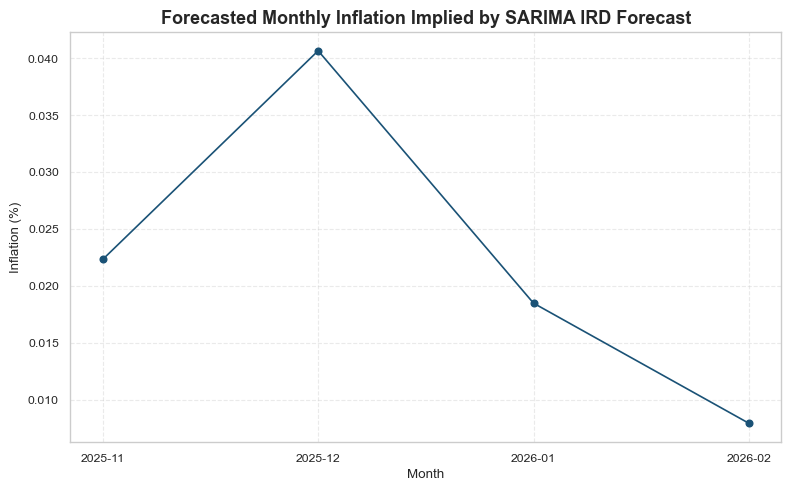

In [76]:
plt.figure(figsize=(8,5))

plt.plot(
    inflation_results.index.astype(str),
    inflation_results["Forecasted_inflation_%"],
    marker="o",
    color="#1A5276"
)

plt.title(
    "Forecasted Monthly Inflation Implied by SARIMA IRD Forecast",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Inflation (%)")

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# CONCLUSIONS

This study evaluated several forecasting models for the IRD index, including statistical and machine learning approaches. Based on the comparison of error metrics (RMSE, MSE, MAE, and MAPE), the SARIMA model achieved the best predictive performance, indicating its ability to capture both temporal dynamics and seasonal patterns in the IRD series.

Using the mathematical structure of the index, the SARIMA forecasts were also used to recover the implied monthly inflation rate. Since the IRD follows an exponential interpolation within each month, the inflation rate can be obtained from the ratio between the end-of-month IRD value and the previous month's final value. The results suggest relatively stable inflation dynamics over the forecast horizon.

Despite these advantages, this methodology has several limitations. First, the recovered inflation depends entirely on the accuracy of the IRD forecast; forecasting errors may propagate directly into the inflation estimates. Second, the method assumes that the exponential interpolation structure of the IRD perfectly reflects the CPI dynamics within the month, which may not fully capture short-term price shocks or irregular movements. Third, SARIMA models rely on historical patterns and may perform poorly under structural economic changes or unexpected shocks.

Overall, the proposed framework demonstrates that forecasting the IRD and recovering inflation from its mathematical formulation can provide a useful and interpretable tool for short-term inflation analysis. Future research could explore more advanced models, such as hybrid statistical–machine learning approaches, to further improve forecasting accuracy and robustness.

# REFERENCES

Banco Central de Reserva del Perú. Índice de reajuste diario (serie PD38031DD). https://estadisticas.bcrp.gob.pe/estadisticas/series/diarias/resultados/PD38031DD/html/2024-01-01/2026-02-28/


Bruno, M., & Easterly, W. (1998). Inflation crises and long-run growth. *Journal of Monetary economics, 41*(1), 3-26.


Fischer, S. (1993). The role of macroeconomic factors in growth. *Journal of monetary economics, 32*(3), 485-512.


Lucas, R. E. (1973). Some international evidence on output-inflation tradeoffs. *The American economic review, 63*(3), 326-334.